# Imports

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import os
from all_gcl_manuscript.paths import REPO_DIR
from all_gcl_manuscript import style

FIG_DIR = os.path.join(REPO_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
style.set_rc_params()

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Load data

In [ ]:
from all_gcl_manuscript.utils import restore_numpy_arrays
from all_gcl_manuscript.paths import DATASET_DIR, ALL_GCL_TABLE

all_gcl_df = pd.read_parquet(os.path.join(DATASET_DIR, ALL_GCL_TABLE))
all_gcl_df = restore_numpy_arrays(all_gcl_df)

Restoring numpy arrays in column: chirp_snippets
Restoring numpy arrays in column: chirp_triggertimes_snippets
Restoring numpy arrays in column: bar_snippets
Restoring numpy arrays in column: bar_triggertimes_snippets
Restoring numpy arrays in column: srf


In [9]:
from all_gcl_manuscript.dataframe import filter_df

all_gcl_df = filter_df(
    df=all_gcl_df,
    condition_filter=True,
    quality_filter=True,
    location_filter=True,
    genline_filter=True,
    rf_quality_filter=False,
    verbose=True,
)

Filtering condition. Removing 19% of the data.
Filtering quality. Removing 30% of the data.
Filtering location. Removing 6% of the data.
Filtering genline. Removing 0% of the data.


In [10]:
all_gcl_df['nasal_temporal_pos_um'] = -all_gcl_df['temporal_nasal_pos_um']

## Prepare data

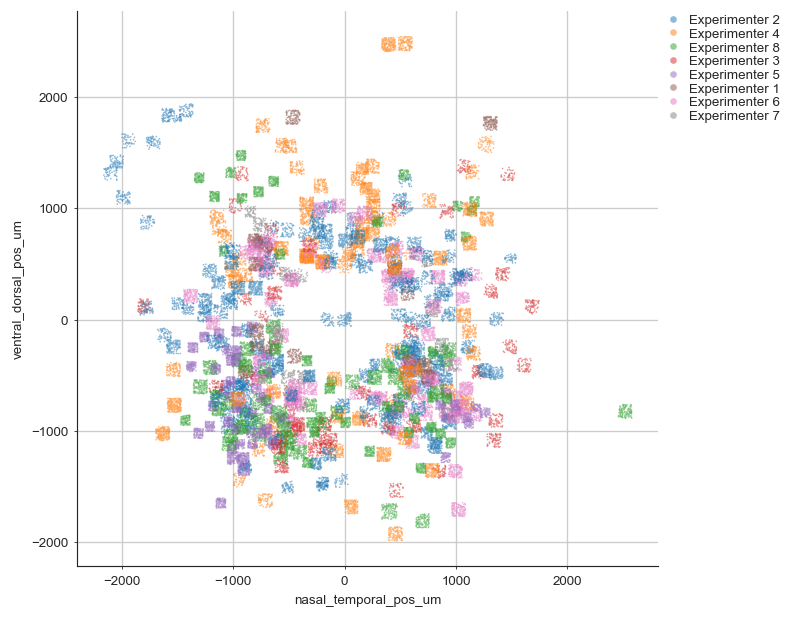

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(
    ax=ax, data=all_gcl_df,
    x='nasal_temporal_pos_um', y='ventral_dorsal_pos_um', hue='experimenter',
    s=1, ec='none', alpha=0.5
)
ax.set_aspect('equal')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), markerscale=4)
ax.grid()
plt.show()

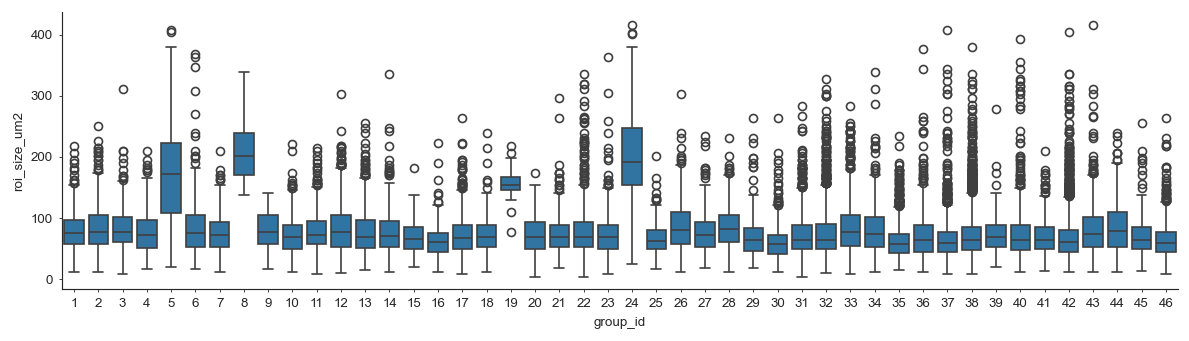

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
sns.boxplot(ax=ax, data=all_gcl_df, x='group_id', y='roi_size_um2')
plt.show()

In [13]:
vmax = np.log2(2)
r_max = 2000

print(vmax)

1.0


In [14]:
from all_gcl_manuscript.density import compute_normalized_kde_ratio

group_vals = np.asarray(all_gcl_df['group_id'].values)
x = np.asarray(all_gcl_df['nasal_temporal_pos_um'].values)
y = np.asarray(all_gcl_df['ventral_dorsal_pos_um'].values)

res = compute_normalized_kde_ratio(
    x=x,
    y=y,
    groups=group_vals,
    r_max=r_max,
    grid_size=51,
    bw_method=1.0,
)

xx = res["xx"]
yy = res["yy"]
outside_circle = res["outside_circle"]
dens_all = res["dens_all"]
group_ids = res["group_ids"]
norm_ratio = res["norm_ratio"]

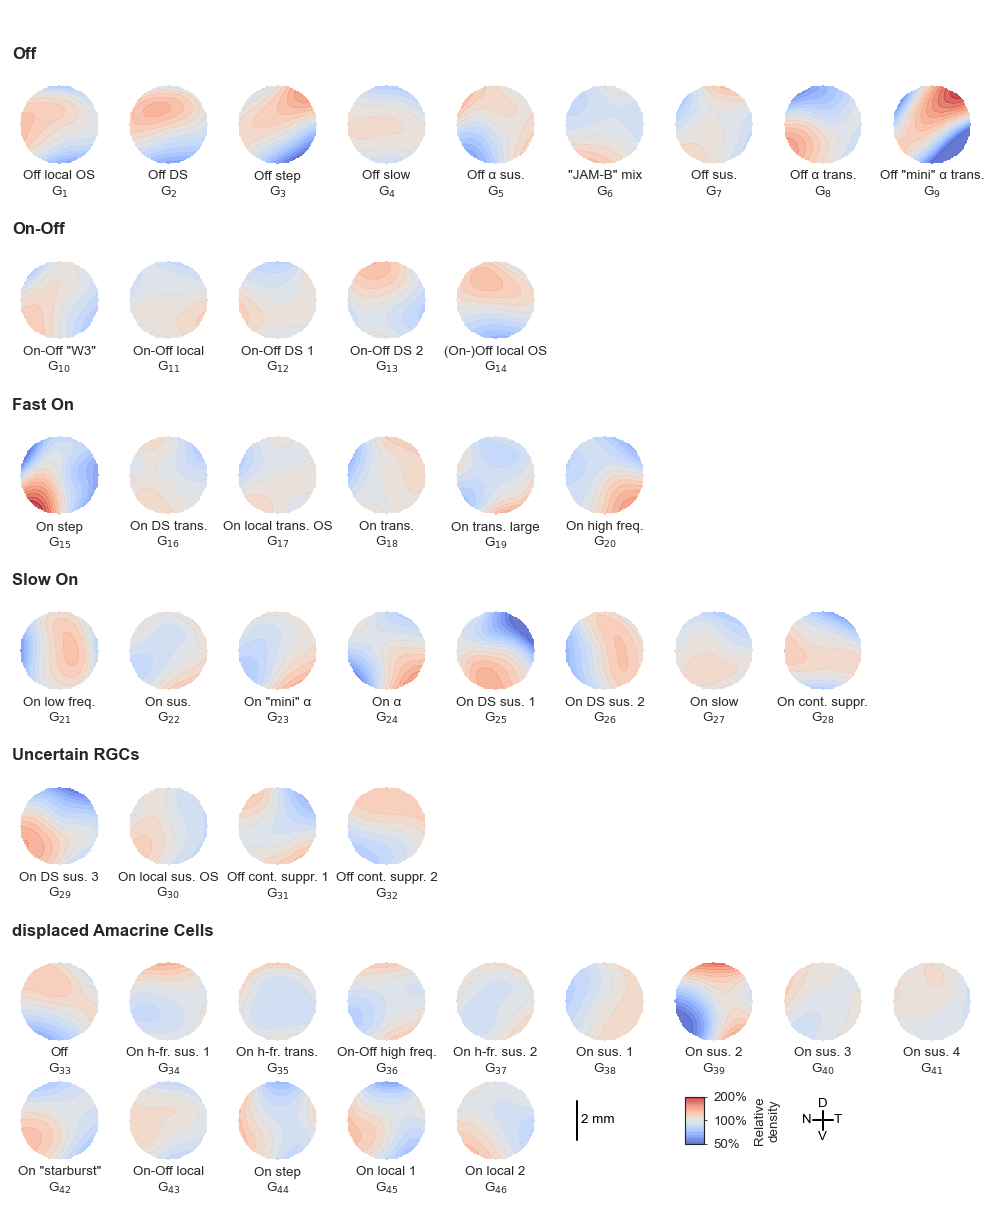

In [19]:
from all_gcl_manuscript import labels

cmap = 'coolwarm'
scatter_kwargs = dict(alpha=0.5, s=0.5, c="black", edgecolors="none", linewidth=0.5)
suptitle = None

n_groups = len(group_ids)

mosaic = [
    ["S1"] * 9,
    list(range(1, 10)),
    ["S2"] * 9,
    list(range(10, 15)) + ["."] * 4,
    ["S3"] * 9,
    list(range(15, 21)) + ["."] * 3,
    ["S4"] * 9,
    list(range(21, 29)) + ["."] * 1,
    ["S5"] * 9,
    list(range(29, 33)) + ["."] * 5,
    ["S6"] * 9,
    list(range(33, 42)),
    list(range(42, 47)) + ["b", "c", "a", "."],
]

gap = 0.2
height_ratios = (gap, 1, gap, 1, gap, 1, gap, 1, gap, 1, gap, 1, 1)

fig, axs = plt.subplot_mosaic(
    mosaic,
    figsize=(8.3, 10),
    sharex=False,
    sharey=False,
    height_ratios=height_ratios,
)

sns.despine(bottom=True, top=True, left=True, right=True)

for name, ax in axs.items():
    if name not in ["c"] and not str(name).startswith('S'):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", 'box')
        ax.set_xlim(-r_max, +r_max)
        ax.set_ylim(-r_max, +r_max)

for si, supergroup in enumerate(
    ['Off', 'On-Off', 'Fast On', 'Slow On', 'Uncertain RGCs', 'displaced Amacrine Cells'],
    start=1
):
    ax = axs[f'S{si}']
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0, 0.5, "\n\n" + supergroup, va='center', weight='bold', ha='left',
            fontsize=plt.rcParams['axes.titlesize'], clip_on=False, zorder=200)

for gid in group_ids:
    ax = axs[int(gid)]
    ax.set_xlabel(
        f"{labels.baden_group_id_to_group_name(gid, shorten=True)}" + "\n" + rf"G$_{{{gid}}}$",
        va="top", ha="center")
    
    # Select rows for scatter overlay
    sel = (group_vals == gid)
    norm = np.log2(norm_ratio[gid]).copy()
    norm[outside_circle] = np.nan

    # Contours and filled
    contour = ax.contourf(
        xx,
        yy,
        np.clip(norm, -vmax, vmax),
        levels=np.linspace(-vmax, +vmax, 21),
        cmap=cmap,
        alpha=0.8,
    )
    #ax.scatter(df.loc[sel, 'x'], df.loc[sel, 'y'], **scatter_kwargs)

plt.tight_layout(h_pad=0, w_pad=-1)

tdist = 50
axs["a"].plot([-500, 500], [0, 0], c='k', dash_capstyle='butt', clip_on=False)
axs["a"].plot([0, 0], [-500, 500], c='k', dash_capstyle='butt', clip_on=False)
axs["a"].text(-500 - tdist, 0, 'N', c='k', va='center', ha='right')
axs["a"].text(+500 + tdist, 0, 'T', c='k', va='center', ha='left')
axs["a"].text(0, -500 - tdist, 'V', c='k', va='top', ha='center')
axs["a"].text(0, +500 + tdist, 'D', c='k', va='bottom', ha='center')

axs["b"].plot([-0.7*r_max, -0.7*r_max], [-1000, 1000], c='k', dash_capstyle='butt', clip_on=False)
axs["b"].text(-0.7*r_max + 200, 0, '2 mm', c='k', va='center', ha='left')

cbar = plt.colorbar(contour, ax=axs[1], cax=axs["c"], ticks=(+1, 0, -1),
                    shrink=0.6, label='Relative\ndensity')
cbar.ax.set_yticklabels(['200%', '100%', '50%']) 
pos = axs["c"].get_position()
axs["c"].set_position([pos.x0 + pos.width * 0.2, pos.y0 + pos.height * 0.2, pos.width * 0.2, pos.height * 0.6])

plt.savefig(os.path.join(FIG_DIR, 'celltype_density_profiles.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'celltype_density_profiles.pdf'), dpi=300, bbox_inches='tight')